# Memory Usage Analysis Across Workflows and Datasets

This notebook analyzes memory usage of configurations across different 
workflow-dataset combinations. We compute:
- Percentiles (90th, 95th, max) for successful runs
- Boxplot statistics for runs with anticipated memory exceeding a threshold
- Percentages of failed configurations

**Note:** You need to first run the `python -m experiments.debugging.download_data` script to download the data.

In [1]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

WORKFLOW_CLASSES = [
    "lcdb.workflow.sklearn.KNNWorkflow",
    "lcdb.workflow.sklearn.LibLinearWorkflow",
    "lcdb.workflow.sklearn.LibSVMWorkflow",
    "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    "lcdb.workflow.xgboost.XGBoostWorkflow",
]

# IO paths
DATA_DIR = Path("./data")
OUTPUT_DIR = DATA_DIR / "memory_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_P90 = OUTPUT_DIR / "p90_memory_by_workflow_dataset.csv"
COMBINED_BINS = OUTPUT_DIR / "memory_bins_all_workflows.csv"
SUCCESSFUL_STATS = OUTPUT_DIR / "successful_memory_stats.csv"
ANTICIPATED_STATS = OUTPUT_DIR / "anticipated_memory_stats.csv"

# Node / core layout (Surf Snellius -- Genoa partition)
NODE_MEM_GB = 336.0
NODE_CORES = 192

# Binning baseline
BASELINE_MIN_GB = 1.7    # ≤1.7 = full-node bin
INCLUDE_ANTICIPATED_ERRORS = True

In [2]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def load_workflow_csv(wf: str, data_dir: Path) -> pd.DataFrame:
    f = data_dir / f"{wf}.csv"
    if not f.exists():
        print(f"[WARN] Missing CSV for workflow: {wf} (expected {f})")
        return pd.DataFrame()
    df = pd.read_csv(f)
    if "m:workflow" not in df.columns:
        df["m:workflow"] = wf
    return df

def _floor_one_decimal(x: float) -> float:
    return math.floor(x * 10.0) / 10.0

def get_cores(memory_per_core_gb: float, number_of_nodes: int = 1) -> int:
    total_memory = NODE_MEM_GB * number_of_nodes
    total_cores = NODE_CORES * number_of_nodes
    if memory_per_core_gb <= 0:
        return 0
    max_by_mem = int(total_memory // memory_per_core_gb)
    return int(min(max_by_mem, total_cores))


def _id_sortable(series: pd.Series):
    try:
        vals = pd.to_numeric(series, errors="coerce").dropna().astype(int).tolist()
        return sorted(set(vals))
    except Exception:
        return sorted(set(series.astype(str)))

In [3]:
# core-based bins
def compute_core_based_bins() -> Tuple[List[float], List[str]]:
    edges = [0.0, BASELINE_MIN_GB]
    candidate_core_counts = [192, 96, 64, 48, 32, 24, 16, 12, 8, 4, 2, 1]
    for cores in candidate_core_counts:
        raw = NODE_MEM_GB / cores
        floored = _floor_one_decimal(raw)
        if floored > edges[-1] and floored < 64.0:
            edges.append(floored)
    edges.append(64.0)
    edges.append(float("inf"))
    labels = []
    for i in range(1, len(edges) - 2):
        labels.append(f"≤{edges[i]:.1f}")
    labels.append("≤64")
    labels.append(">64")
    return edges, labels

In [4]:
# successful memory stats
def _add_anticipated_flag(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a boolean column indicating if anticipated memory error occurred,
    based on the presence of anticipated_memory (in GB).
    """
    tmp = df.copy()
    tmp["_anticipated_mem_error"] = tmp["anticipated_memory"].notna()
    return tmp


def compute_successful_memory_stats(df: pd.DataFrame) -> pd.DataFrame:
    # extract the successful runs only by excluding anticipated memory errors
    tmp = _add_anticipated_flag(df)
    ok = tmp[~tmp["_anticipated_mem_error"]].copy()
    if ok.empty:
        return pd.DataFrame(columns=[
            "m:workflow", "m:openmlid", "p90_gb", "p95_gb", "max_gb",
            "allocated_cores", "flagged_frac", "forced_over_64gb"
        ])

    g_all = tmp.groupby(["m:workflow", "m:openmlid"], dropna=False)
    g_ok  = ok.groupby(["m:workflow", "m:openmlid"], dropna=False)["m:memory"]

    p90 = g_ok.quantile(0.90, interpolation="linear").rename("p90")
    p95 = g_ok.quantile(0.95, interpolation="linear").rename("p95")
    mx  = g_ok.max().rename("max")

    out = pd.concat([p90, p95, mx], axis=1).reset_index()

    # convert to GiB
    out["p90_gb"] = out["p90"] / (1024 ** 3)
    out["p95_gb"] = out["p95"] / (1024 ** 3)
    out["max_gb"] = out["max"] / (1024 ** 3)

    flagged_frac = g_all["_anticipated_mem_error"].mean().rename("flagged_frac").reset_index()
    out = out.merge(flagged_frac, on=["m:workflow", "m:openmlid"], how="left")
    out["flagged_frac"] = out["flagged_frac"].fillna(0.0)
    out["forced_over_64gb"] = out["flagged_frac"] >= 0.05

    out["allocated_cores"] = out["p90_gb"].apply(lambda gb: get_cores(gb, 1) if pd.notna(gb) else np.nan)

    return out[["m:workflow", "m:openmlid", "p90_gb", "p95_gb", "max_gb",
                "allocated_cores", "flagged_frac", "forced_over_64gb"]].sort_values(
                ["m:workflow", "m:openmlid"]).reset_index(drop=True)


In [5]:
# anticipated memory stats
def compute_anticipated_box_stats(df: pd.DataFrame) -> pd.DataFrame:
    tmp = _add_anticipated_flag(df)
    flagged = tmp[tmp["_anticipated_mem_error"]].copy()
    if flagged.empty:
        return pd.DataFrame(columns=[
            "m:workflow", "m:openmlid", "n_flagged", "flagged_frac",
            "min_gb", "q1_gb", "q2_gb", "q3_gb", "max_gb"
        ])

    g_all = tmp.groupby(["m:workflow", "m:openmlid"], dropna=False)

    # use anticipated_memory (already in GiB)
    g_fl  = flagged.groupby(["m:workflow", "m:openmlid"], dropna=False)["anticipated_memory"]

    q1 = g_fl.quantile(0.25, interpolation="linear").rename("q1_gb")
    q2 = g_fl.quantile(0.50, interpolation="linear").rename("q2_gb")
    q3 = g_fl.quantile(0.75, interpolation="linear").rename("q3_gb")
    mn = g_fl.min().rename("min_gb")
    mx = g_fl.max().rename("max_gb")
    n_flagged = g_fl.count().rename("n_flagged")

    out = pd.concat([mn, q1, q2, q3, mx, n_flagged], axis=1).reset_index()

    flagged_frac = g_all["_anticipated_mem_error"].mean().rename("flagged_frac").reset_index()
    out = out.merge(flagged_frac, on=["m:workflow", "m:openmlid"], how="left")
    out["flagged_frac"] = out["flagged_frac"].fillna(0.0)

    return out.sort_values(["m:workflow", "m:openmlid"]).reset_index(drop=True)


In [6]:
def build_memory_bins(stats_df: pd.DataFrame, workflow: str,
                      bin_edges: List[float], bin_labels: List[str]) -> pd.DataFrame:
    wf_df = stats_df[stats_df["m:workflow"] == workflow].copy()
    if wf_df.empty:
        base = pd.DataFrame({"memory_bin_gb": bin_labels})
        base["m:workflow"] = workflow
        base["datasets"] = [[] for _ in bin_labels]
        base["dataset_count"] = 0
        return base[["m:workflow", "memory_bin_gb", "datasets", "dataset_count"]]

    wf_df["memory_bin_gb"] = pd.cut(
        wf_df["p90_gb"].astype(float),
        bins=bin_edges,
        labels=bin_labels,
        right=True,
        include_lowest=True,
        duplicates="drop"
    )

    agg = (
        wf_df.groupby("memory_bin_gb", dropna=False, observed=False)["m:openmlid"]
             .apply(_id_sortable)
             .reset_index()
             .rename(columns={"m:openmlid": "datasets"})
    )

    full = pd.DataFrame({"memory_bin_gb": bin_labels})
    out = full.merge(agg, on="memory_bin_gb", how="left")
    out["datasets"] = out["datasets"].apply(lambda v: v if isinstance(v, list) else [])
    out["dataset_count"] = out["datasets"].apply(len)
    out["m:workflow"] = workflow

    return out[["m:workflow", "memory_bin_gb", "datasets", "dataset_count"]]

In [7]:
def save_simple_per_workflow_bins(stats_df: pd.DataFrame, bin_edges: List[float],
                                  bin_labels: List[str], out_dir: Path):
    simple_dir = out_dir / "workflow_bins_simple"
    simple_dir.mkdir(parents=True, exist_ok=True)

    numeric_map = {}
    for lbl in bin_labels:
        if lbl == ">64":
            numeric_map[lbl] = 65.0
        elif lbl.startswith("≤"):
            numeric_map[lbl] = float(lbl.replace("≤", ""))
        else:
            numeric_map[lbl] = float(lbl.strip("≤"))

    for wf in sorted(stats_df["m:workflow"].unique()):
        wf_df = stats_df[stats_df["m:workflow"] == wf].copy()
        wf_df["memory_bin_gb"] = pd.cut(
            wf_df["p90_gb"].astype(float),
            bins=bin_edges,
            labels=bin_labels,
            right=True,
            include_lowest=True,
            duplicates="drop"
        )
        wf_df["memory_bin_gb"] = wf_df["memory_bin_gb"].astype(str).map(numeric_map)
        wf_df.loc[wf_df["memory_bin_gb"] > 64.0, "memory_bin_gb"] = np.nan
        wf_df = wf_df.sort_values("m:openmlid")

        wf_short = wf.split(".")[-1].replace("Workflow", "")

        out_path = simple_dir / f"{wf_short}_simple_bins.csv"
        wf_df[["m:openmlid", "memory_bin_gb"]].to_csv(out_path, index=False, header=False)

In [8]:
ensure_dir(OUTPUT_DIR)

# 1) Load all workflow CSVs
dfs = [load_workflow_csv(wf, DATA_DIR) for wf in WORKFLOW_CLASSES]
dfs = [d for d in dfs if not d.empty]
if not dfs:
    raise FileNotFoundError("No workflow CSVs found in DATA_DIR.")
df_all = pd.concat(dfs, ignore_index=True)

# 2) Successful-only stats (used for reporting AND binning)
succ_stats = compute_successful_memory_stats(df_all)
succ_stats.to_csv(SUCCESSFUL_STATS, index=False)

# 3) Build bins directly from successful stats (using p90_gb)
bin_edges, bin_labels = compute_core_based_bins()
all_bins = []
for wf in sorted(succ_stats["m:workflow"].unique()):
    wf_bins = build_memory_bins(succ_stats, wf, bin_edges=bin_edges, bin_labels=bin_labels)
    all_bins.append(wf_bins)
combined_bins = pd.concat(all_bins, ignore_index=True)
combined_bins.to_csv(COMBINED_BINS, index=False)

# 4) workflow_bins_simple outputs
save_simple_per_workflow_bins(succ_stats, bin_edges=bin_edges, bin_labels=bin_labels, out_dir=OUTPUT_DIR)

# 5) Anticipated-only box-stats
anticipated_stats = compute_anticipated_box_stats(df_all)
anticipated_stats.to_csv(ANTICIPATED_STATS, index=False)

print(f"\nWrote:")
print(f"- {SUCCESSFUL_STATS.name}\t-> {SUCCESSFUL_STATS}")
print(f"- {COMBINED_BINS.name}\t-> {COMBINED_BINS}")
print(f"- {ANTICIPATED_STATS.name}\t-> {ANTICIPATED_STATS}")
print(f"- workflow_bins_simple/*.csv\t-> {OUTPUT_DIR / 'workflow_bins_simple'}")


Wrote:
- successful_memory_stats.csv	-> data/memory_analysis/successful_memory_stats.csv
- memory_bins_all_workflows.csv	-> data/memory_analysis/memory_bins_all_workflows.csv
- anticipated_memory_stats.csv	-> data/memory_analysis/anticipated_memory_stats.csv
- workflow_bins_simple/*.csv	-> data/memory_analysis/workflow_bins_simple


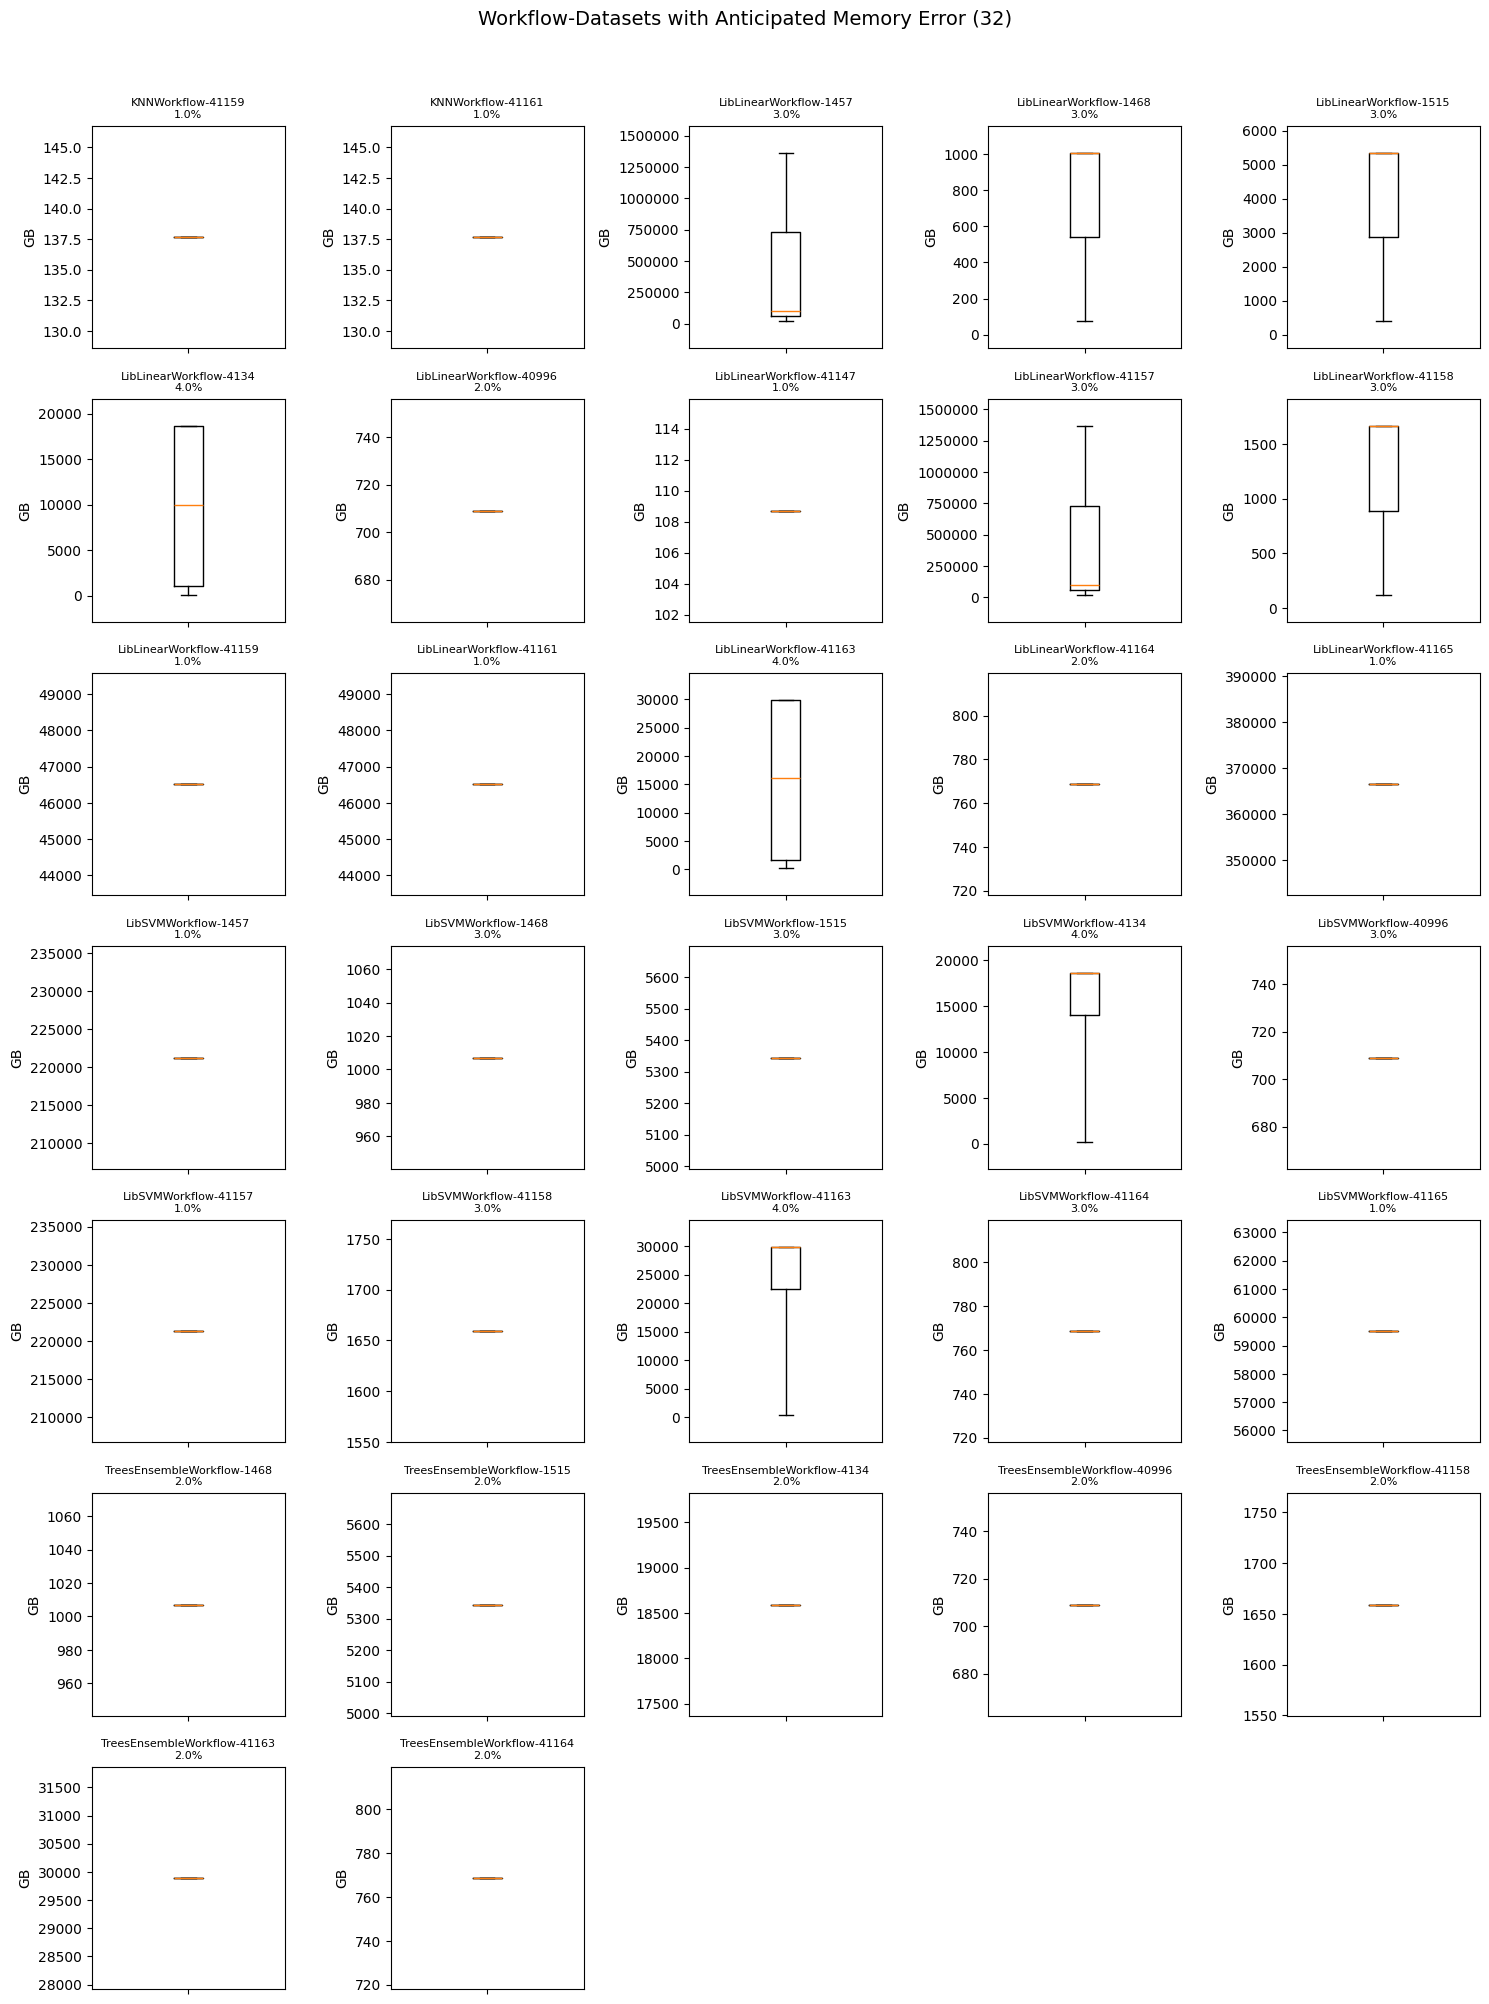

[Saved plot as data/memory_analysis/anticipated_memory_boxplots.png


In [9]:
import matplotlib.ticker as mticker

try:
    stats = pd.read_csv(ANTICIPATED_STATS)
    n = len(stats)
    if n > 0:
        cols = 5
        rows = math.ceil(n / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 2.8))
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = np.array([axes])
        axes = axes.reshape(rows, cols)

        idx = 0
        for r in range(rows):
            for c in range(cols):
                ax = axes[r, c]
                if idx >= n:
                    ax.axis("off")
                    continue

                row = stats.iloc[idx]
                box_data = {
                    "label": "",
                    "whislo": row["min_gb"],
                    "q1": row["q1_gb"],
                    "med": row["q2_gb"],
                    "q3": row["q3_gb"],
                    "whishi": row["max_gb"],
                    "fliers": []
                }
                ax.set_ylabel("GB")

                ax.bxp([box_data], showfliers=False)

                # format y-axis
                ax.set_ylabel("GB")
                ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
                ax.ticklabel_format(style='plain', axis='y')

                # add padding room around min/max
                y_min, y_max = ax.get_ylim()
                margin = 0.1 * (y_max - y_min)
                ax.set_ylim(y_min - margin, y_max + margin)

                # title
                wf_short = str(row["m:workflow"]).split(".")[-1]
                ds = int(row["m:openmlid"]) if pd.notna(row["m:openmlid"]) else row["m:openmlid"]
                frac_pct = f"{float(row['flagged_frac'])*100:.1f}%"
                ax.set_title(f"{wf_short}-{ds}\n{frac_pct}", fontsize=8)

                idx += 1

        fig.suptitle(f"Workflow-Datasets with Anticipated Memory Error ({n})", fontsize=14, y=1.02)
        plt.tight_layout()
        out_png = OUTPUT_DIR / "anticipated_memory_boxplots.png"
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"[Saved plot as {out_png}")
    else:
        print("No anticipated-memory groups; skipping boxplot grid.")
except Exception as e:
    print(f"Skipped boxplot grid due to error: {e}")
